<a href="https://colab.research.google.com/github/sam098761212-glitch/Leeseungsoo-AI_CLASS/blob/main/%EA%B8%B0%EA%B3%84%ED%95%99%EC%8A%B5%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_9_28_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import seaborn as sns


columns = [
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'class'
]


df = pd.read_csv('car.data', names=columns)


df.head(10)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [6]:
# 다른방법
dt = pd.read_csv('car.data', names=columns)

dt.columns = ['buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'class']

dt.head(10)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [11]:
X = df.drop("class",axis = 1)
y = df["class"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for column in columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

df

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2
...,...,...,...,...,...,...,...
1723,1,1,3,2,1,2,1
1724,1,1,3,2,1,0,3
1725,1,1,3,2,0,1,2
1726,1,1,3,2,0,2,1


In [12]:
# 의사결정나무

from sklearn.tree import DecisionTreeClassifier
model_D = DecisionTreeClassifier()
model_D.fit(X_train, y_train)

pred_df_D = model_D.predict(X_test)

from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, pred_df_D))

0.9797687861271677


In [13]:
# 랜덤포레스트

from sklearn.ensemble import RandomForestClassifier
model_R = RandomForestClassifier()
model_R.fit(X_train,y_train)

pred_df_R = model_R.predict(X_test)

from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, pred_df_R))

0.9739884393063584


In [14]:
# 로지스틱회귀

from sklearn.linear_model import LogisticRegression
model_D = LogisticRegression()
model_D.fit(X_train,y_train)

pred_df_L = model_D.predict(X_test)

from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, pred_df_L))

0.6734104046242775


In [15]:
# 성능비교 와 평가지표

from sklearn.metrics import classification_report, confusion_matrix

# DecisionTree

print(classification_report(y_test, pred_df_D))

cmD = confusion_matrix(y_test,pred_df_D)
print(cmD)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        83
           1       0.93      0.93      0.93        15
           2       0.99      0.99      0.99       235
           3       0.92      0.92      0.92        13

    accuracy                           0.98       346
   macro avg       0.95      0.95      0.95       346
weighted avg       0.98      0.98      0.98       346

[[ 80   1   2   0]
 [  0  14   0   1]
 [  2   0 233   0]
 [  1   0   0  12]]


In [16]:
# RandomForest

print(classification_report(y_test, pred_df_R))

cmR = confusion_matrix(y_test, pred_df_R)
print(cmR)

              precision    recall  f1-score   support

           0       0.96      0.93      0.94        83
           1       0.93      0.93      0.93        15
           2       0.98      1.00      0.99       235
           3       1.00      0.92      0.96        13

    accuracy                           0.97       346
   macro avg       0.97      0.94      0.96       346
weighted avg       0.97      0.97      0.97       346

[[ 77   1   5   0]
 [  1  14   0   0]
 [  1   0 234   0]
 [  1   0   0  12]]


In [17]:
# LogisticRegression

print(classification_report(y_test, pred_df_L))

cmL = confusion_matrix(y_test, pred_df_L)
print(cmL)

              precision    recall  f1-score   support

           0       0.46      0.20      0.28        83
           1       0.00      0.00      0.00        15
           2       0.72      0.91      0.80       235
           3       0.18      0.15      0.17        13

    accuracy                           0.67       346
   macro avg       0.34      0.32      0.31       346
weighted avg       0.60      0.67      0.62       346

[[ 17   0  60   6]
 [  0   0  15   0]
 [ 18   0 214   3]
 [  2   0   9   2]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# svm은 시험 X

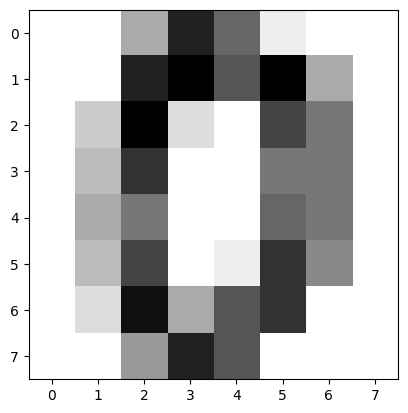

In [18]:
# 손글씨데이터

import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split

digits = datasets.load_digits()
plt.imshow(digits.images[0], cmap=plt.cm.gray_r, interpolation='nearest')

In [19]:
print(digits)

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]]), 'target': array([0, 1, 2, ..., 8, 9, 8]), 'frame': None, 'feature_names': ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', '

In [24]:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
X = data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [25]:
# 의사결정나무
model_D = DecisionTreeClassifier(random_state=42)
model_D.fit(X_train, y_train)
pred_df_D = model_D.predict(X_test)
print('DecisionTree 정확도:', accuracy_score(y_test, pred_df_D))

DecisionTree 정확도: 0.825


In [26]:
# 랜덤포레스트
model_R = RandomForestClassifier(random_state=42)
model_R.fit(X_train, y_train)
pred_df_R = model_R.predict(X_test)
print('RandomForest 정확도:', accuracy_score(y_test, pred_df_R))


RandomForest 정확도: 0.9611111111111111


In [27]:
# 로지스틱회귀: 충분히 학습하도록 최대 반복 횟수 증가
model_L = LogisticRegression(max_iter=5000)
model_L.fit(X_train, y_train)
pred_df_L = model_L.predict(X_test)
print('LogisticRegression 정확도:', accuracy_score(y_test, pred_df_L))

LogisticRegression 정확도: 0.9583333333333334


In [28]:
from sklearn.neighbors import KNeighborsClassifier
# KNN: 원본 파일과 같은 이웃 수 6 사용
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)
pred_df_K = knn.predict(X_test)
print('KNN 정확도:', accuracy_score(y_test, pred_df_K))

KNN 정확도: 0.9805555555555555


In [29]:
# 성능 비교와 평가 지표
# classification_report: 정밀도, 재현율, F1 점수 등
# confusion_matrix: 행은 실제 숫자, 열은 예측 숫자 (0~9 순서)
print('\n[DecisionTree 분류 보고서]')
print(classification_report(y_test, pred_df_D, zero_division=0))
cmD = confusion_matrix(y_test, pred_df_D)
print('혼동행렬:\n', cmD)



[DecisionTree 분류 보고서]
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.84      0.72      0.78        36
           2       0.78      0.80      0.79        35
           3       0.79      0.81      0.80        37
           4       0.86      0.86      0.86        36
           5       0.88      0.95      0.91        37
           6       0.81      0.83      0.82        36
           7       0.84      0.86      0.85        36
           8       0.71      0.69      0.70        35
           9       0.82      0.75      0.78        36

    accuracy                           0.82       360
   macro avg       0.82      0.82      0.82       360
weighted avg       0.82      0.82      0.82       360

혼동행렬:
 [[35  0  0  0  0  0  0  0  1  0]
 [ 0 26  2  1  1  0  1  1  4  0]
 [ 1  0 28  3  0  1  2  0  0  0]
 [ 0  0  2 30  0  1  1  1  0  2]
 [ 1  0  1  1 31  0  1  0  1  0]
 [ 0  0  0  0  1 35  0  0  0  1]
 [ 1  1  0  0

In [30]:
print('\n[RandomForest 분류 보고서]')
print(classification_report(y_test, pred_df_R, zero_division=0))
cmR = confusion_matrix(y_test, pred_df_R)
print('혼동행렬:\n', cmR)


[RandomForest 분류 보고서]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360

혼동행렬:
 [[35  0  0  0  1  0  0  0  0  0]
 [ 0 35  0  0  0  1  0  0  0  0]
 [ 1  0 34  0  0  0  0  0  0  0]
 [ 0  0  0 36  0  0  0  0  0  1]
 [ 0  1  0  0 35  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0

In [31]:
print('\n[LogisticRegression 분류 보고서]')
print(classification_report(y_test, pred_df_L, zero_division=0))
cmL = confusion_matrix(y_test, pred_df_L)
print('혼동행렬:\n', cmL)



[LogisticRegression 분류 보고서]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.89      0.89      0.89        36
           2       0.97      1.00      0.99        35
           3       0.95      1.00      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      0.97      0.97        37
           6       1.00      0.97      0.99        36
           7       1.00      0.97      0.99        36
           8       0.86      0.86      0.86        35
           9       1.00      0.94      0.97        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360

혼동행렬:
 [[35  0  1  0  0  0  0  0  0  0]
 [ 0 32  0  1  0  0  0  0  3  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  1  0 36  0  0  0  0]
 [ 0  0

In [32]:
print('\n[KNN 분류 보고서]')
print(classification_report(y_test, pred_df_K, zero_division=0))
cmK = confusion_matrix(y_test, pred_df_K)
print('혼동행렬:\n', cmK)


[KNN 분류 보고서]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.89      0.91        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

혼동행렬:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35